# Notatka: Proces trenowania modeli i decyzje architektoniczne

## 1. Źródło i ograniczenie danych

**Źródło:** ChEMBL baza SQLite (wersja 36), pobrana przez FTP.
**Ograniczenie:** tylko 3 cele biologiczne związane z Alzheimerem: `CHEMBL220`, `CHEMBL4822`, `CHEMBL3177`.
**Filtry ETL:**
- `canonical_smiles IS NOT NULL`
- `pchembl_value IS NOT NULL`
- `potential_duplicate` = NULL lub 0
- Imputacja jednostek: jeśli brak `standard_units` a `standard_value` w zakresie 0.01..1e6 → przyjmujemy nM
- Obliczenie `pIC50 = -log10(standard_value * 1e-9)` dla nM, wpp. `pchembl_value`
- Usunięcie `pIC50` NULL/nieskończonych, deduplikacja po `canonical_smiles`
- Finalna liczba próbek: **~15 723** unikalnych cząsteczek.

## 2. Cechy (Feature Engineering)

Dwa modele → dwie reprezentacje:

### MLP (fingerprinty)
- **Morgan fingerprint (ECFP)** z RDKit, radius=2, 2048 bitów
- Opcjonalnie: **MACCS keys** (167 bitów)
- Opcjonalnie: **deskryptory molekularne** (standaryzowane Z-score na zbiorze treningowym):
  `mw_freebase`, `alogp`, `hba`, `hbd`, `psa`, `rtb`, `aromatic_rings`, `qed_weighted`

### GNN (graf molekularny)
- **Cechy węzłów (atomów):**
  - one-hot numeru atomowego (13 wartości: 1,5,6,7,8,9,14,15,16,17,34,35,53)
  - one-hot hybrydyzacji (SP, SP2, SP3, SP3D, SP3D2)
  - one-hot chiral tag (CHI_UNSPECIFIED, CHI_TETRAHEDRAL_CW, CCW)
  - numeryczne: degree, formal_charge, num_hs, total_valence, num_radical, is_aromatic, is_in_ring
- **Cechy krawędzi (wiązań):**
  - one-hot typu wiązania (SINGLE, DOUBLE, TRIPLE, AROMATIC)
  - one-hot stereo (NONE, Z, E, CIS, TRANS)
  - flagi: is_conjugated, is_in_ring

## 3. Podział danych (Splitting)

Dwie strategie, obie 80/10/10:

| Strategia | Opis |
|---|---|
| **Random split** | Losowe przetasowanie i podział. Szybsze, ale może powodować data leakage. |
| **Scaffold split** | Grupowanie cząsteczek według szkieletu (Murcko scaffold). Całe grupy do train/val/test. **Wymagane na ocenę 3.5+**. |
| **Family split** (eksperymentalny) | Klasteryzacja K-Means fingerprintów → PCA → hold-out całych rodzin. |

## 4. Architektury modeli

### MLPBaseline (`src/models/models.py`)
- Warstwy: `Input → [Linear → BatchNorm? → ReLU → Dropout] × N warstw → Linear(→1)`
- Domyślne warstwy ukryte: `[512, 128]`, opcjonalnie `[1024, 512, 256]`
- Dropout: 0.2, BatchNorm: wyłączona domyślnie
- Inicjalizacja wag: `kaiming_normal`

### GNNRegressor (`src/models/gnn.py`)
- `Node proj → [GINEConv + BatchNorm + ReLU + Dropout + Residual] × 4 warstwy → JK → Pooling → [deskryptory?] → Head MLP`
- **GINEConv** (GIN with Edge features) — teoretycznie silniejszy od GCN (test izomorfizmu WL)
- **Pooling:** domyślnie `mean`, dostępne: `add`, `attention`
- **JumpingKnowledge (JK):** konkatenacja wyjść wszystkich warstw — zapobiega over-smoothing
- **Połączenia residualne:** w każdej warstwie

## 5. Hiperparametry

| Parametr | MLP | GNN |
|---|---|---|
| Learning rate | 3e-4 | 3e-4 |
| Batch size | 64 | 64 |
| Weight decay | 1e-5 | 1e-5 |
| Dropout | 0.2 | 0.15 |
| Warstwy ukryte | 512→128 (lub 1024→512→256) | 128×4 |
| Funkcja straty | Huber (delta=1.0) | Huber (delta=1.0) |
| Early stopping | patience=15, min_delta=1e-4 | patience=15, min_delta=1e-4 |
| Scheduler | ReduceLROnPlateau / CosineAnnealing | ReduceLROnPlateau / CosineAnnealing |
| Max epoki | 200 | 200 |
| Mixed precision | AMP (jeśli CUDA) | AMP (jeśli CUDA) |

**Funkcja straty:** Huber Loss zamiast MSE — mniej wrażliwa na outliery.

## 6. Proces trenowania

1. **Seed everything**
2. **Build loadery** — MLP: TensorDataset, GNN: PyG DataLoader
3. **Pętla treningowa:** Forward (AMP), Backprop (gradient clipping max_norm=1.0), Adam, Scheduler, Early stopping po val_loss
4. **Zapis najlepszego modelu** (najniższa val_loss)
5. **Cache'owanie** do `.pt` — przy kolejnym uruchomieniu wczytuje się z cache

## 7. Narzędzia i monitoring

- **MLflow** — logowanie parametrów, metryk per-epokowych (train_loss, val_loss, val_r2, lr) i finalnych (R², RMSE, MAE)
- **Optuna** — tuning hiperparametrów GNN (50 triali, TPE sampler, MedianPruner)
- **Model cache** — `.pt` pliki w `processed_data/model_cache/`

> **Uwaga:** Wszystkie modele trenuje się przez CLI (`bash experiments/run_all.sh`) lub pojedyncze komendy `python scripts/train.py`. Ten notebook tylko ładuje wyniki z cache i MLflow.

In [1]:
import numpy as np
import polars as pl
import torch
from pathlib import Path

from src.models.data import fp_from_smiles, build_mlp_loaders
from src.models.models import MLPBaseline
from src.models.pipeline import results_table, get_model_cache_path
from src.models.training import predict_arrays
from src._config import PROCESSED_DATA, MODEL_CACHE

pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(100)


/home/computer/Repositories/ml_chembl/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


polars.config.Config

In [2]:
df = pl.read_parquet(PROCESSED_DATA / "ChEMBL_processed.parquet")

df_temp = df.with_columns(
    pl.col("canonical_smiles").map_elements(fp_from_smiles, return_dtype=pl.Object).alias("fp")
)
df_clean = df_temp.filter(
    (pl.col("fp").is_not_null()) & 
    (pl.col("pIC50").is_not_null()) &
    (pl.col("pIC50").is_not_nan())
)
print(f"Liczba probek: {len(df_clean)}")

DESCRIPTOR_COLS = ["mw_freebase", "alogp", "hba", "hbd", "psa", "rtb", "aromatic_rings", "qed_weighted"]


Liczba probek: 15723


In [3]:
# Wczytaj wyniki z cache modeli (bez odpalania treningu)
results_table.clear()

cache_dir = Path(MODEL_CACHE)
if cache_dir.exists():
    for pt_file in sorted(cache_dir.glob('*.pt')):
        try:
            cached = torch.load(pt_file, map_location="cpu", weights_only=False)
            result = cached.get("result")
            if result and "model" in result and "split" in result:
                dedup_key = (
                    result["model"],
                    result["split"],
                    result.get("seed"),
                    str(result.get("mlp_hidden_sizes")),
                    result.get("scheduler_type"),
                )
                r2_val = result.get("r2_val")
                rmse_val = result.get("rmse_val")
                mae_val = result.get("mae_val")
                if r2_val is None or rmse_val is None or mae_val is None:
                    continue
                existing = [
                    i for i, r in enumerate(results_table)
                    if (r["model"], r["split"], r.get("seed"),
                        str(r.get("mlp_hidden_sizes")), r.get("scheduler_type")) == dedup_key
                ]
                if existing:
                    existing_idx = existing[0]
                    if r2_val > results_table[existing_idx].get("r2_val", -float("inf")):
                        results_table[existing_idx] = result
                else:
                    results_table.append(result)
        except Exception:
            pass

print(f'Zaladowano {len(results_table)} wynikow z cache.')


Zaladowano 38 wynikow z cache.


## Porownanie wszystkich wariantow

model,split,seed,epochs,epochs_trained,best_epoch,lr,batch_size,weight_decay,pooling,gnn_hidden_dim,gnn_num_layers,gnn_dropout,mlp_hidden_sizes,mlp_dropout,scheduler_type,mlp_use_maccs,mlp_use_batch_norm,loss_fn,avg_train_loss,avg_val_loss,best_val_loss,r2_val,rmse_val,mae_val
str,str,i64,i64,i64,i64,f64,i64,f64,str,i64,i64,f64,list[i64],f64,str,bool,bool,str,f64,f64,f64,f64,f64,f64
"""MLP""","""random""",42,200,79,64,0.0003,64,0.00001,"""mean""",128,4,0.15,null,null,null,null,null,"""huber""",0.246651,0.229419,0.185202,0.757982,0.64586,0.462955
"""MLP""","""random""",42,200,79,64,0.0003,64,0.00001,"""mean""",128,4,0.15,null,0.2,"""plateau""",true,true,"""huber""",0.246651,0.229419,0.185202,0.757982,0.64586,0.462955
"""MLP""","""random""",99,200,65,50,0.0003,64,0.00001,"""mean""",128,4,0.15,null,null,null,null,null,"""huber""",0.177196,0.221251,0.199918,0.737925,0.67209,0.485136
"""MLP""","""random""",99,200,65,50,0.0003,64,0.00001,"""mean""",128,4,0.15,null,0.2,"""plateau""",false,false,"""huber""",0.177196,0.221251,0.199918,0.737925,0.67209,0.485136
"""MLP""","""random""",123,200,54,39,0.0003,64,0.00001,"""mean""",128,4,0.15,null,null,null,null,null,"""huber""",0.193644,0.220689,0.200654,0.736787,0.673547,0.487414
"""MLP""","""random""",123,200,54,39,0.0003,64,0.00001,"""mean""",128,4,0.15,null,0.2,"""plateau""",false,false,"""huber""",0.193644,0.220689,0.200654,0.736787,0.673547,0.487414
"""MLP""","""random""",7,200,53,38,0.0003,64,0.00001,"""mean""",128,4,0.15,null,0.2,"""plateau""",false,false,"""huber""",0.199979,0.225006,0.201587,0.736039,0.674504,0.491756
"""MLP""","""random""",7,200,53,38,0.0003,64,0.00001,"""mean""",128,4,0.15,null,null,null,null,null,"""huber""",0.199979,0.225006,0.201587,0.736039,0.674504,0.491756
"""GNN""","""random""",99,200,127,112,0.0003,64,0.00001,"""mean""",128,4,0.15,null,0.2,"""plateau""",false,false,"""huber""",0.333895,0.319236,0.224633,0.704358,0.713835,0.523567


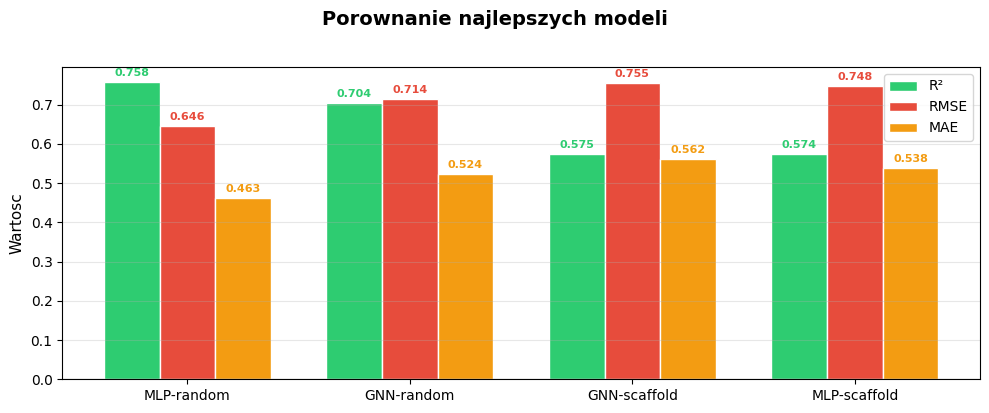

model,split,seed,r2_val,rmse_val,mae_val,best_val_loss,best_epoch,epochs_trained,lr,batch_size
str,str,i64,f64,f64,f64,f64,i64,i64,f64,i64
"""MLP""","""random""",42,0.757982,0.64586,0.462955,0.185202,64,79,0.0003,64
"""GNN""","""random""",99,0.704358,0.713835,0.523567,0.224633,112,127,0.0003,64
"""GNN""","""scaffold""",123,0.574849,0.755155,0.561651,0.245972,74,89,0.0005,64
"""MLP""","""scaffold""",99,0.573729,0.74773,0.53803,0.238138,61,76,0.0003,64


In [4]:
import matplotlib.pyplot as plt

if not results_table:
    print("Brak wynikow w cache. Uruchom najpierw: bash experiments/run_all.sh")
else:
    df_all = pl.DataFrame(results_table)

    ALL_COLS = [
        "model", "split", "seed", "epochs", "epochs_trained", "best_epoch",
        "lr", "batch_size", "weight_decay", "pooling",
        "gnn_hidden_dim", "gnn_num_layers", "gnn_dropout",
        "mlp_hidden_sizes", "mlp_dropout", "scheduler_type",
        "mlp_use_maccs", "mlp_use_batch_norm", "loss_fn",
        "avg_train_loss", "avg_val_loss", "best_val_loss", "r2_val", "rmse_val", "mae_val",
    ]
    cols = [c for c in ALL_COLS if c in df_all.columns]
    display(df_all.select(cols).sort("r2_val", descending=True))

    df_best = (
        df_all
        .group_by("model", "split")
        .agg(pl.all().sort_by("r2_val", descending=True).first())
        .sort("r2_val", descending=True)
    )

    labels = [f"{r['model']}-{r['split']}" for r in df_best.iter_rows(named=True)]
    x = np.arange(len(labels))
    width = 0.25

    r2 = df_best["r2_val"].to_list()
    rmse = df_best["rmse_val"].to_list()
    mae = df_best["mae_val"].to_list()

    fig, ax = plt.subplots(figsize=(10, 4))
    fig.suptitle(
        "Porownanie najlepszych modeli",
        fontsize=14, fontweight="bold", y=1.02,
    )

    bars1 = ax.bar(x - width, r2, width, label="R\u00b2",
                   color="#2ecc71", edgecolor="white")
    bars2 = ax.bar(x, rmse, width, label="RMSE",
                   color="#e74c3c", edgecolor="white")
    bars3 = ax.bar(x + width, mae, width, label="MAE",
                   color="#f39c12", edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel("Wartosc", fontsize=11)
    ax.legend(fontsize=10)
    ax.axhline(y=0, color="gray", linewidth=0.8)
    ax.grid(axis='y', alpha=0.3)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom",
                fontsize=8, color="#2ecc71", fontweight="bold")
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom",
                fontsize=8, color="#e74c3c", fontweight="bold")
    for bar in bars3:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom",
                fontsize=8, color="#f39c12", fontweight="bold")

    plt.tight_layout()
    plt.show()

    COLS_SHOW = ["model", "split", "seed", "r2_val", "rmse_val",
                 "mae_val", "best_val_loss", "best_epoch",
                 "epochs_trained", "lr", "batch_size"]
    cols2 = [c for c in COLS_SHOW if c in df_best.columns]
    display(df_best.select(cols2))


In [5]:
if results_table:
    df_all = pl.DataFrame(results_table)
    summary = (
        df_all.group_by("model", "split")
        .agg([
            pl.col("r2_val").mean().alias("r2_val_mean"),
            pl.col("r2_val").std().alias("r2_val_std"),
            pl.col("rmse_val").mean().alias("rmse_val_mean"),
            pl.col("rmse_val").std().alias("rmse_val_std"),
            pl.col("mae_val").mean().alias("mae_val_mean"),
            pl.col("mae_val").std().alias("mae_val_std"),
            pl.col("r2_val").count().alias("n_seeds"),
        ])
        .sort("r2_val_mean", descending=True)
    )
    print("Ensemble (srednia +- std po seedach):")
    display(summary)


Ensemble (srednia +- std po seedach):


model,split,r2_val_mean,r2_val_std,rmse_val_mean,rmse_val_std,mae_val_mean,mae_val_std,n_seeds
str,str,f64,f64,f64,f64,f64,f64,u32
"""MLP""","""random""",0.742183,0.009778,0.666501,0.012772,0.481815,0.011915,8
"""GNN""","""random""",0.676324,0.023774,0.746479,0.027221,0.549154,0.02184,8
"""MLP""","""scaffold""",0.483799,0.051229,0.81722,0.035906,0.610368,0.032921,14
"""GNN""","""scaffold""",0.469181,0.087835,0.839103,0.055292,0.627611,0.045921,8


## Ensemble MLP-deep na scaffold

Glebsze MLP (1024 -> 512 -> 256, CosineAnnealing) - usrednienie predykcji z 4 seedow.

In [6]:
IMPROVED_MLP_SEEDS = [42, 123, 7, 99]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader, val_loader, test_loader = build_mlp_loaders(
    df_clean, split_type="scaffold", batch_size=256, seed=42,
    descriptor_cols=DESCRIPTOR_COLS, use_maccs=True,
)
sample = next(iter(train_loader))[0]
input_size = sample.shape[1]

all_preds = []
all_targets = None
for seed in IMPROVED_MLP_SEEDS:
    cfg = {
        "model_type": "MLP", "split_type": "scaffold", "seed": seed,
        "epochs": 200, "lr": 0.0003, "batch_size": 64,
        "early_stopping_patience": 15, "min_delta": 0.0001, "weight_decay": 1e-5,
        "pooling": "mean", "gnn_hidden_dim": 128, "gnn_num_layers": 4, "gnn_dropout": 0.15, "loss_fn": "huber",
        "mlp_descriptor_cols": DESCRIPTOR_COLS, "mlp_use_maccs": True, "mlp_use_batch_norm": True,
        "mlp_hidden_sizes": [1024, 512, 256], "mlp_dropout": 0.2, "scheduler_type": "cosine",
    }
    cache_path = get_model_cache_path(cfg, namespace="default")
    if cache_path.exists():
        model = MLPBaseline(
            input_size=input_size, use_batch_norm=True,
            hidden_sizes=[1024, 512, 256], dropout=0.2,
        ).to(device)
        cached = torch.load(cache_path, map_location=device, weights_only=False)
        model.load_state_dict(cached["model_state_dict"])
        targets, preds = predict_arrays(model, val_loader, device)
        all_preds.append(preds)
        if all_targets is None:
            all_targets = targets

if all_preds:
    ensemble_preds = np.mean(all_preds, axis=0)
    from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
    r2_ens = float(r2_score(all_targets, ensemble_preds))
    rmse_ens = float(np.sqrt(mean_squared_error(all_targets, ensemble_preds)))
    mae_ens = float(mean_absolute_error(all_targets, ensemble_preds))
    print(f'Ensemble MLP-deep (seed avg, n={len(all_preds)}):')
    print(f'val R\u00b2={r2_ens:.4f}  RMSE={rmse_ens:.4f}  MAE={mae_ens:.4f}')
else:
    print("Brak modeli w cache. Uruchom najpierw: bash experiments/run_all.sh")


Ensemble MLP-deep (seed avg, n=1):
val R²=0.4876  RMSE=0.7723  MAE=0.5928


## GNN z deskryptorami + JumpingKnowledge

GNN z deskryptorami molekularnymi (MW, logP, HBA...) konkatowanymi po poolingu
oraz JumpingKnowledge (laczenie cech ze wszystkich warstw GNN).

In [7]:
if results_table:
    df_gnn = pl.DataFrame(results_table).filter(pl.col('model') == 'GNN')
    if len(df_gnn) > 0:
        gnn_cols = ["model", "split", "seed", "gnn_hidden_dim", "gnn_num_layers",
                    "gnn_dropout", "pooling", "r2_val", "rmse_val", "mae_val"]
        cols = [c for c in gnn_cols if c in df_gnn.columns]
        display(df_gnn.select(cols).sort("r2_val", descending=True))
    else:
        print("Brak wynikow GNN w cache.")


model,split,seed,gnn_hidden_dim,gnn_num_layers,gnn_dropout,pooling,r2_val,rmse_val,mae_val
str,str,i64,i64,i64,f64,str,f64,f64,f64
"""GNN""","""random""",99,128,4,0.15,"""mean""",0.704358,0.713835,0.523567
"""GNN""","""random""",7,128,4,0.15,"""mean""",0.692544,0.727957,0.534874
"""GNN""","""random""",123,128,4,0.15,"""mean""",0.690943,0.729851,0.534326
"""GNN""","""random""",42,128,4,0.15,"""mean""",0.689566,0.731474,0.537658
"""GNN""","""random""",42,192,4,0.1,"""mean""",0.686067,0.735585,0.539043
"""GNN""","""random""",7,128,4,0.15,"""mean""",0.657065,0.768813,0.569654
"""GNN""","""random""",123,128,4,0.15,"""mean""",0.651839,0.774649,0.572102
"""GNN""","""random""",99,128,4,0.15,"""mean""",0.638206,0.789669,0.582005
"""GNN""","""scaffold""",123,256,5,0.05,"""mean""",0.574849,0.755155,0.561651


## Krzywa uczenia

Krzywa uczenia odczytana z MLflow (dane zebrane podczas treningu przez `run_all.sh`).

In [ ]:
import mlflow
from pathlib import Path
from scipy.ndimage import uniform_filter1d
from src._config import MLFLOW_DB_URI

def _resolve_mlflow_uri():
    uri = str(MLFLOW_DB_URI)
    if uri.startswith("sqlite:///") and not uri.startswith("sqlite:////"):
        relative = uri.removeprefix("sqlite:///")
        return f"sqlite:////{Path(relative).resolve().as_posix()}"
    return uri

mlflow.set_tracking_uri(_resolve_mlflow_uri())
client = mlflow.MlflowClient()
experiment = mlflow.get_experiment_by_name("ml_chembl_baselines")

def _get_best_run(model_type, split_type):
    """Znajdz najlepszy (najwyzsze r2_val) nie-cache run dla comba."""
    runs = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=f"tags.model_type = '{model_type}' and "
                      f"tags.split_type = '{split_type}' and "
                      f"tags.from_cache = 'false'",
        order_by=["metrics.r2_val DESC"],
        max_results=1,
    )
    if len(runs) == 0:
        return None
    return runs.iloc[0]

def _get_metric_history(client, run_id, key):
    hist = client.get_metric_history(run_id, key)
    return np.array([m.step for m in hist]), np.array([m.value for m in hist])

combos = [("GNN", "scaffold"), ("GNN", "random"), ("MLP", "scaffold"), ("MLP", "random")]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Krzywe uczenia - wszystkie modele (z MLflow)",
             fontsize=15, fontweight="bold")

for idx, (model_type, split_type) in enumerate(combos):
    run_row = _get_best_run(model_type, split_type)
    if run_row is None:
        continue
    run_id = run_row["run_id"]
    r2_final = run_row.get("metrics.r2_val", "?")

    steps_tl, tl = _get_metric_history(client, run_id, "train_loss")
    steps_vl, vl = _get_metric_history(client, run_id, "val_loss")
    steps_vr, vr = _get_metric_history(client, run_id, "val_r2")
    _, lrs = _get_metric_history(client, run_id, "lr")

    window = max(1, len(tl) // 10)
    tl_s = uniform_filter1d(tl, size=window, mode="nearest")
    vl_s = uniform_filter1d(vl, size=window, mode="nearest")
    vr_s = uniform_filter1d(vr, size=window, mode="nearest")

    label = f"{model_type}-{split_type}"

    # Loss
    ax = axes[0, idx]
    ax.plot(steps_tl, tl, alpha=0.1, color="#2ecc71")
    ax.plot(steps_tl, tl_s, label="Train Loss", color="#2ecc71", linewidth=2)
    ax.plot(steps_vl, vl, alpha=0.1, color="#e74c3c")
    ax.plot(steps_vl, vl_s, label="Val Loss", color="#e74c3c", linewidth=2)
    best_ep = int(np.argmin(vl))
    ax.axvline(x=best_ep, color="gray", linestyle="--", alpha=0.5)
    ax.set_title(f"{label} (R\u00b2={r2_final:.3f})", fontsize=10)
    ax.set_xlabel("Epoka")
    ax.set_ylabel("Loss (Huber)")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

    # R\u00b2
    ax = axes[1, idx]
    ax.axhline(y=0, color="gray", linewidth=0.5, linestyle="--")
    ax.plot(steps_vr, vr, alpha=0.1, color="#3498db")
    ax.plot(steps_vr, vr_s, label="Val R\u00b2", color="#3498db", linewidth=2)
    best_ep_r2 = int(np.argmax(vr))
    ax.axvline(x=best_ep_r2, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Epoka")
    ax.set_ylabel("R\u00b2")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Podsumowanie: najlepsze modele

Szczegolowe porownanie 4 najlepszych modeli: GNN (random, scaffold) i MLP (random, scaffold).
Kazdy model jest reprezentowany przez najlepszy seed (wedlug R² na walidacji).

Device: cuda

GNN-random: 8 candidates


seed,r2_val,gnn_hidden_dim,gnn_num_layers,gnn_dropout,cache_path
i64,f64,i64,i64,f64,str
99,0.704358,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_a3f730f600af9f18.pt"""
7,0.692544,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_872c05c70b05b508.pt"""
123,0.690943,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_b5a1d2cca802a45c.pt"""
42,0.689566,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_1b1c57bd603daa65.pt"""
42,0.686067,192,4,0.1,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_39f372358e84ba0b.pt"""
7,0.657065,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_26ba63eda430dcc6.pt"""
123,0.651839,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_b70234d7a16b15b6.pt"""
99,0.638206,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_286696e4d233c198.pt"""


  SELECTED: seed=99, r2=0.7044, cache=/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_a3f730f600af9f18.pt

GNN-scaffold: 8 candidates


seed,r2_val,gnn_hidden_dim,gnn_num_layers,gnn_dropout,cache_path
i64,f64,i64,i64,f64,str
123,0.574849,256,5,0.05,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/gnn_tuning_9999e15456dad768.pt"""
42,0.53724,192,4,0.2,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/gnn_tuning_bf77211bff212169.pt"""
7,0.513608,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_e59f27985ae1eccd.pt"""
99,0.489747,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_5b85974581ed3cf2.pt"""
123,0.465274,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_34c4dcded9c792cf.pt"""
99,0.460507,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_bd90f7f917881ded.pt"""
42,0.427348,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_5290b1af61cead8a.pt"""
7,0.284873,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_7456e35c7f9b3362.pt"""


  SELECTED: seed=123, r2=0.5748, cache=/home/computer/Repositories/ml_chembl/processed_data/model_cache/gnn_tuning_9999e15456dad768.pt

MLP-random: 8 candidates


seed,r2_val,gnn_hidden_dim,gnn_num_layers,gnn_dropout,cache_path
i64,f64,i64,i64,f64,str
42,0.757982,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_bd0a05c61761a368.pt"""
42,0.757982,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_c6d5fc046dac89d1.pt"""
99,0.737925,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_5077c7e5502a0e1e.pt"""
99,0.737925,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_a9026c243dbc4cc8.pt"""
123,0.736787,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_533ce99678c46830.pt"""
123,0.736787,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_91bb6b2e4683f636.pt"""
7,0.736039,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_33da5eb65b8493cb.pt"""
7,0.736039,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_5b00309649ef4eb3.pt"""


  SELECTED: seed=42, r2=0.7580, cache=/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_bd0a05c61761a368.pt

MLP-scaffold: 14 candidates


seed,r2_val,gnn_hidden_dim,gnn_num_layers,gnn_dropout,cache_path
i64,f64,i64,i64,f64,str
99,0.573729,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_44569efd7dbe2905.pt"""
42,0.536339,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_2481bc7a8877d463.pt"""
42,0.53539,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_dde114aa37bc1c11.pt"""
42,0.527701,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_e7f7c0a0effd139b.pt"""
123,0.523438,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_8f1303a92ca4781c.pt"""
123,0.487175,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_df10dbf2bacb642c.pt"""
7,0.480841,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_e15d840f99fc281c.pt"""
99,0.474246,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_47daab3c6f4d9e7e.pt"""
42,0.470047,128,4,0.15,"""/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_2cc222007c2b4240.pt"""


  SELECTED: seed=99, r2=0.5737, cache=/home/computer/Repositories/ml_chembl/processed_data/model_cache/default_44569efd7dbe2905.pt
  GNN-random: seed=99, R²=0.7044, RMSE=0.7138, MAE=0.5236
  GNN-scaffold: seed=123, R²=0.5748, RMSE=0.7552, MAE=0.5617
  MLP-random: seed=42, R²=0.7580, RMSE=0.6459, MAE=0.4630
  MLP-scaffold: seed=99, R²=0.5737, RMSE=0.7477, MAE=0.5380


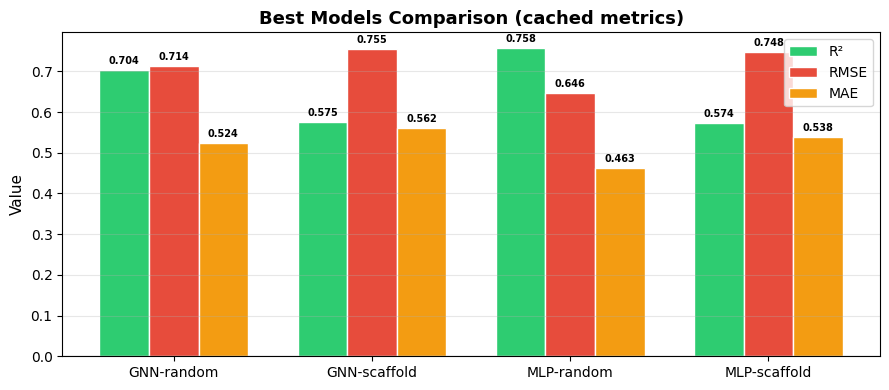


Konfiguracja najlepszych modeli:
  GNN h=128, L=4, dr=0.15, pool=mean, bs=64, ep=127
  GNN h=256, L=5, dr=0.05, pool=mean, bs=64, ep=89
  GNN h=128, L=4, dr=0.15, pool=mean, bs=64, ep=79
  MLP hidden=[1024, 512, 256], bn=True, dr=0.2, bs=64, ep=76

Szczegolowe zestawienie 4 najlepszych modeli (z cache):


label,model,split,seed,r2,rmse,mae
str,str,str,i64,f64,f64,f64
"""GNN-random""","""GNN""","""random""",99,0.704358,0.713835,0.523567
"""GNN-scaffold""","""GNN""","""scaffold""",123,0.574849,0.755155,0.561651
"""MLP-random""","""MLP""","""random""",42,0.757982,0.64586,0.462955
"""MLP-scaffold""","""MLP""","""scaffold""",99,0.573729,0.74773,0.53803


In [8]:
import warnings
warnings.filterwarnings("ignore")

import torch.nn as nn
import torch.nn.functional as F

from src.models.gnn import GNNRegressor
from src.models.models import MLPBaseline
from src.models.data import build_mlp_loaders, build_gnn_loaders
from src.models.training import predict_arrays

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

BEST_COMBOS = [
    ("GNN", "random"),
    ("GNN", "scaffold"),
    ("MLP", "random"),
    ("MLP", "scaffold"),
]

# Find best seed per combo
best_configs = {}
for model_type, split_type in BEST_COMBOS:
    subset = df_all.filter(
        (pl.col("model") == model_type) & (pl.col("split") == split_type)
    )
    if len(subset) == 0:
        continue
    print(f"\n{model_type}-{split_type}: {len(subset)} candidates")
    display(subset.select(["seed", "r2_val", "gnn_hidden_dim", "gnn_num_layers", "gnn_dropout", "cache_path"]).sort("r2_val", descending=True))
    best_row = subset.sort("r2_val", descending=True).row(0, named=True)
    best_configs[(model_type, split_type)] = best_row
    print(f"  SELECTED: seed={best_row['seed']}, r2={best_row['r2_val']:.4f}, cache={best_row.get('cache_path','?')}")

# Load models and collect predictions
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

model_data = []
for model_type, split_type in BEST_COMBOS:
    subset = df_all.filter(
        (pl.col("model") == model_type) & (pl.col("split") == split_type)
    )
    if len(subset) == 0:
        continue
    best = subset.sort("r2_val", descending=True).row(0, named=True)
    model_data.append({
        "label": f"{model_type}-{split_type}",
        "model": model_type,
        "split": split_type,
        "seed": best["seed"],
        "r2": best["r2_val"],
        "rmse": best["rmse_val"],
        "mae": best["mae_val"],
    })
    print(f"  {model_type}-{split_type}: seed={best['seed']}, R\u00b2={best['r2_val']:.4f}, RMSE={best['rmse_val']:.4f}, MAE={best['mae_val']:.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
labels = [md["label"] for md in model_data]
x = np.arange(len(labels))
width = 0.25

r2_vals = [md["r2"] for md in model_data]
rmse_vals = [md["rmse"] for md in model_data]
mae_vals = [md["mae"] for md in model_data]

ax.bar(x - width, r2_vals, width, label="R\u00b2", color="#2ecc71", edgecolor="white")
ax.bar(x, rmse_vals, width, label="RMSE", color="#e74c3c", edgecolor="white")
ax.bar(x + width, mae_vals, width, label="MAE", color="#f39c12", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Value", fontsize=11)
ax.set_title("Best Models Comparison (cached metrics)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.axhline(y=0, color="gray", linewidth=0.8)
ax.grid(axis="y", alpha=0.3)

for bar, val in zip(ax.containers[0], r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=7, fontweight="bold")
for bar, val in zip(ax.containers[1], rmse_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=7, fontweight="bold")
for bar, val in zip(ax.containers[2], mae_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=7, fontweight="bold")

plt.tight_layout()
plt.show()

# Config info
print("\nKonfiguracja najlepszych modeli:")
for md in model_data:
    mt, st = md["model"], md["split"]
    row = df_all.filter((pl.col("model") == mt) & (pl.col("split") == st)).sort("r2_val", descending=True).row(0, named=True)
    hidden = row.get("mlp_hidden_sizes")
    if hidden is not None:
        info = f"  MLP hidden={hidden}, bn={row.get('mlp_use_batch_norm')}, dr={row.get('mlp_dropout')}, bs={row.get('batch_size')}, ep={row.get('epochs_trained')}"
    else:
        info = f"  GNN h={row.get('gnn_hidden_dim')}, L={row.get('gnn_num_layers')}, dr={row.get('gnn_dropout')}, pool={row.get('pooling')}, bs={row.get('batch_size')}, ep={row.get('epochs_trained')}"
    print(info)

print("\nSzczegolowe zestawienie 4 najlepszych modeli (z cache):")
df_summary = pl.DataFrame([
    {k: md[k] for k in ("label", "model", "split", "seed", "r2", "rmse", "mae")}
    for md in model_data
])
display(df_summary)
